<a href="https://colab.research.google.com/github/sachin23-an/backtesting-engine/blob/main/backtesting_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PROJECT 1: Quantitative Backtesting and Risk Analysis Engine
============================================================
Built for: NIFTY 50 (^NSEI), 2019-2024
Strategies: SMA 20/50 Crossover + Bollinger Bands Mean Reversion
Metrics: Sharpe, CAGR, Max Drawdown, Monte Carlo (1000 paths), t-test
Transaction cost: 0.05% per trade


# Project 1: Quantitative Backtesting Engine


In [ ]:
# Strategies: SMA Crossover + Bollinger Bands
# Data: NIFTY 50 (^NSEI), 5 years daily


In [ ]:
# Install and import everything needed
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("All libraries loaded successfully")

All libraries loaded successfully


#Download NIFTY 50 Data

 We use yfinance to get free daily data for NIFTY 50 index.
 NSEI is the ticker symbol for NIFTY 50 on Yahoo Finance

In [ ]:
# Download NIFTY 50 data - 5 years daily
ticker = "^NSEI"
df = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Keep only the Close price column
df = df[['Close']]

# Basic checks
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nMissing values:", df.isnull().sum().values[0])
print("\nDate range:", df.index[0].date(), "to", df.index[-1].date())

/tmp/ipykernel_6049/1216261293.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Shape: (1232, 1)

First 5 rows:
Price              Close
Ticker             ^NSEI
Date                    
2019-01-02  10792.500000
2019-01-03  10672.250000
2019-01-04  10727.349609
2019-01-07  10771.799805
2019-01-08  10802.150391

Last 5 rows:
Price              Close
Ticker             ^NSEI
Date                    
2023-12-22  21349.400391
2023-12-26  21441.349609
2023-12-27  21654.750000
2023-12-28  21778.699219
2023-12-29  21731.400391

Missing values: 0

Date range: 2019-01-02 to 2023-12-29


# Step 2: Calculate Daily Returns


In [ ]:
# Log returns are preferred in quant finance because they are additive over time
# Simple return = (today - yesterday) / yesterday
# Log return = ln(today / yesterday)

In [ ]:
# Calculate simple and log returns
df['simple_return'] = df['Close'].pct_change()
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

# Drop the first row which has NaN returns
df = df.dropna()

# Basic return statistics
print("=== RETURN STATISTICS ===")
print(f"Trading days: {len(df)}")
print(f"\nSimple Returns:")
print(f"  Mean daily return:  {df['simple_return'].mean()*100:.4f}%")
print(f"  Std daily return:   {df['simple_return'].std()*100:.4f}%")
print(f"  Skewness:           {df['simple_return'].skew():.4f}")
print(f"  Kurtosis:           {df['simple_return'].kurtosis():.4f}")
print(f"\nAnnualised (252 trading days):")
print(f"  Annualised Return:  {df['simple_return'].mean()*252*100:.2f}%")
print(f"  Annualised Vol:     {df['simple_return'].std()*np.sqrt(252)*100:.2f}%")

=== RETURN STATISTICS ===
Trading days: 1231

Simple Returns:
  Mean daily return:  0.0642%
  Std daily return:   1.2040%
  Skewness:           -1.2371
  Kurtosis:           18.8633

Annualised (252 trading days):
  Annualised Return:  16.18%
  Annualised Vol:     19.11%


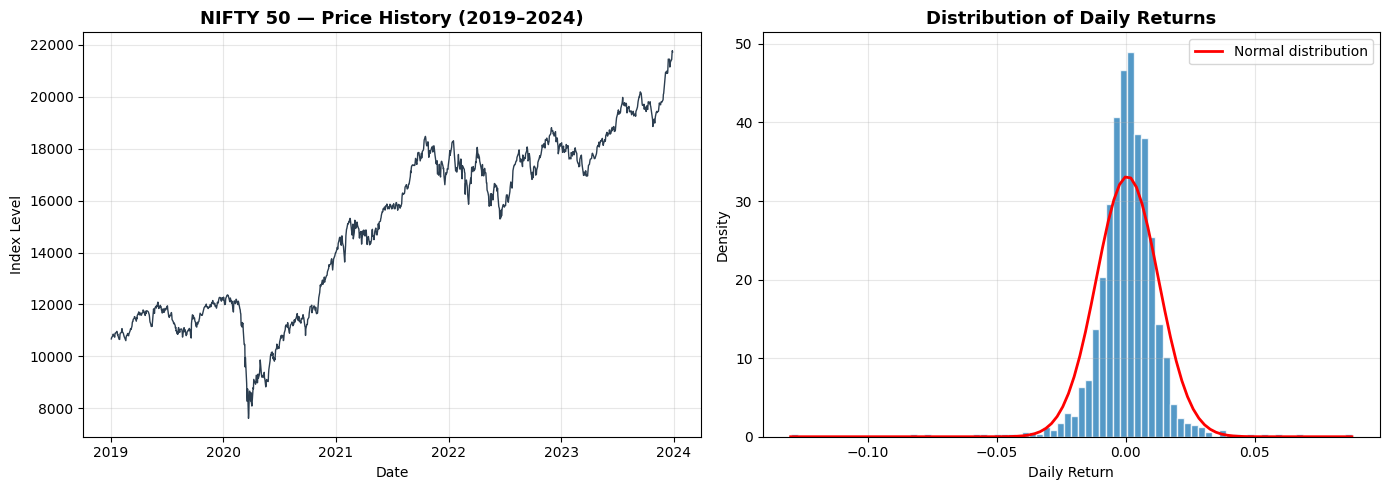

Chart saved as returns_analysis.png


In [ ]:
# Plot 1: Price history and return distribution side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: NIFTY 50 price history
axes[0].plot(df.index, df['Close'], color='#2C3E50', linewidth=1)
axes[0].set_title('NIFTY 50 — Price History (2019–2024)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Index Level')
axes[0].grid(True, alpha=0.3)

# Right chart: Distribution of daily returns
axes[1].hist(df['simple_return'], bins=80, color='#2980B9',
             edgecolor='white', alpha=0.8, density=True)
axes[1].set_title('Distribution of Daily Returns', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

# Add a normal distribution curve for comparison
x = np.linspace(df['simple_return'].min(), df['simple_return'].max(), 100)
normal_curve = stats.norm.pdf(x, df['simple_return'].mean(), df['simple_return'].std())
axes[1].plot(x, normal_curve, color='red', linewidth=2, label='Normal distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('returns_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as returns_analysis.png")

# Step 3: SMA Crossover Strategy

In [ ]:

# Signal: Buy when 20-day SMA crosses above 50-day SMA (golden cross)
# Signal: Sell when 20-day SMA crosses below 50-day SMA (death cross)
# Position: +1 = long, 0 = flat (we do not short the index)
# IMPORTANT: Signal on day T means we trade at day T+1 open
# This prevents look-ahead bias

In [ ]:
# Calculate moving averages
df['SMA_20'] = df['Close'].rolling(20).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()

# Generate raw signal: 1 when SMA20 above SMA50, 0 otherwise
df['SMA_signal_raw'] = np.where(df['SMA_20'] > df['SMA_50'], 1, 0)

# CRITICAL: Shift signal by 1 day to avoid look-ahead bias
# We see today's signal but can only act tomorrow
df['SMA_position'] = df['SMA_signal_raw'].shift(1)

# Calculate strategy returns
# When position is 1: we earn the market return
# When position is 0: we earn nothing (sitting in cash)
df['SMA_return'] = df['SMA_position'] * df['simple_return']

# Count trades (every time position changes)
df['SMA_trade'] = df['SMA_position'].diff().abs()
total_sma_trades = int(df['SMA_trade'].sum())

print("=== SMA CROSSOVER STRATEGY ===")
print(f"Total signals generated: {df['SMA_signal_raw'].sum()}")
print(f"Days in market (long): {int(df['SMA_position'].sum())}")
print(f"Days out of market (cash): {int((df['SMA_position']==0).sum())}")
print(f"Total number of trades: {total_sma_trades}")
print(f"\nFirst few signals:")
print(df[['Close','SMA_20','SMA_50','SMA_signal_raw','SMA_position']].dropna().head(10))

=== SMA CROSSOVER STRATEGY ===
Total signals generated: 790
Days in market (long): 789
Days out of market (cash): 441
Total number of trades: 23

First few signals:
Price              Close        SMA_20        SMA_50 SMA_signal_raw  \
Ticker             ^NSEI                                              
Date                                                                  
2019-03-15  11426.849609  10958.990039  10887.535996              1   
2019-03-18  11462.200195  10995.880029  10903.335000              1   
2019-03-19  11532.400391  11040.452539  10919.436016              1   
2019-03-20  11521.049805  11086.287549  10934.421016              1   
2019-03-22  11456.900391  11122.360059  10947.516016              1   
2019-03-25  11354.250000  11150.580078  10957.498008              1   
2019-03-26  11483.250000  11185.160059  10970.731016              1   
2019-03-27  11445.049805  11213.407568  10983.733008              1   
2019-03-28  11570.000000  11250.142578  11000.381016  

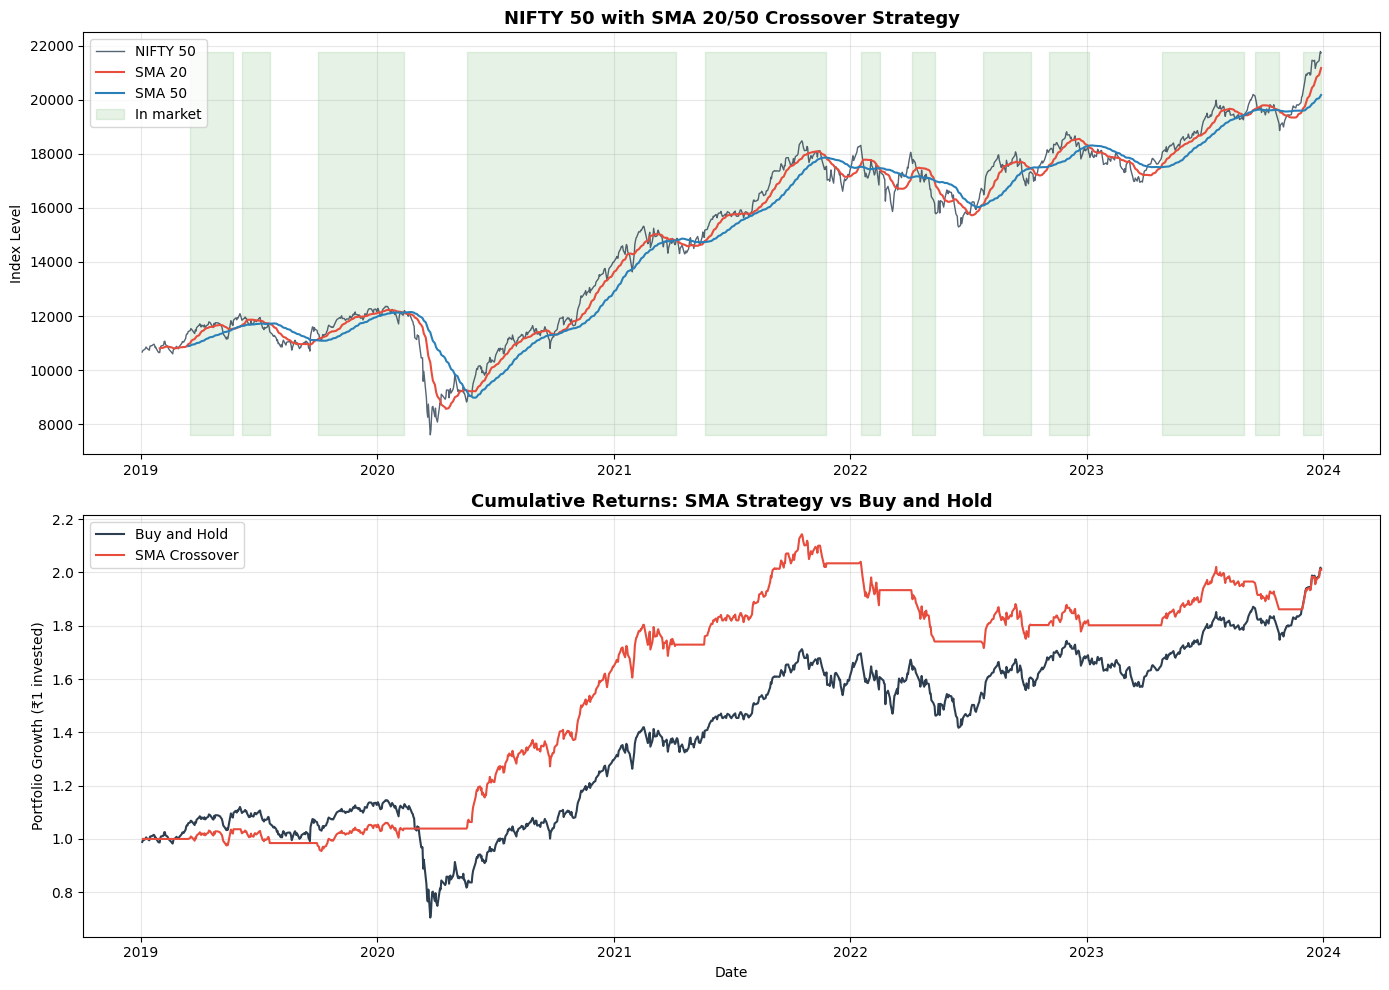

Chart saved as sma_strategy.png


In [ ]:
# Visualise the SMA strategy
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: Price with SMAs and buy/sell signals
axes[0].plot(df.index, df['Close'], color='#2C3E50', linewidth=1, label='NIFTY 50', alpha=0.8)
axes[0].plot(df.index, df['SMA_20'], color='#E74C3C', linewidth=1.5, label='SMA 20')
axes[0].plot(df.index, df['SMA_50'], color='#2980B9', linewidth=1.5, label='SMA 50')

# Shade the periods when we are in the market
in_market = df['SMA_position'] == 1
axes[0].fill_between(df.index, df['Close'].min(), df['Close'].max(),
                     where=in_market, alpha=0.1, color='green', label='In market')

axes[0].set_title('NIFTY 50 with SMA 20/50 Crossover Strategy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Index Level')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Bottom chart: Cumulative returns comparison
cumulative_market = (1 + df['simple_return']).cumprod()
cumulative_sma = (1 + df['SMA_return']).cumprod()

axes[1].plot(df.index, cumulative_market, color='#2C3E50', linewidth=1.5, label='Buy and Hold')
axes[1].plot(df.index, cumulative_sma, color='#E74C3C', linewidth=1.5, label='SMA Crossover')
axes[1].set_title('Cumulative Returns: SMA Strategy vs Buy and Hold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Portfolio Growth (₹1 invested)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sma_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sma_strategy.png")

## Step 4: Bollinger Bands Mean Reversion Strategy


In [ ]:
# Upper Band = 20-day SMA + 2 * 20-day std
# Lower Band = 20-day SMA - 2 * 20-day std
# Signal: Buy when price touches lower band (oversold)
# Signal: Sell/exit when price touches upper band (overbought)
# This is a mean reversion strategy — opposite logic to SMA crossover

In [ ]:
# Generate Bollinger Band signals
bb_position = []
current_position = 0

for i in range(len(df)):
    close = df['Close'].iloc[i].item()
    lower = df['BB_lower'].iloc[i].item()
    upper = df['BB_upper'].iloc[i].item()

    if pd.isna(lower) or pd.isna(upper):
        bb_position.append(0)
        continue

    if current_position == 0 and close < lower:
        current_position = 1  # Enter long
    elif current_position == 1 and close > upper:
        current_position = 0  # Exit long

    bb_position.append(current_position)

df['BB_position_raw'] = bb_position

# Shift by 1 to avoid look-ahead bias
df['BB_position'] = pd.Series(bb_position, index=df.index).shift(1)

# Calculate strategy returns
df['BB_return'] = df['BB_position'] * df['simple_return']

# Count trades
df['BB_trade'] = df['BB_position'].diff().abs()
total_bb_trades = int(df['BB_trade'].sum())

print("=== BOLLINGER BANDS STRATEGY ===")
print(f"Days in market (long): {int(df['BB_position'].sum())}")
print(f"Days out of market: {int((df['BB_position']==0).sum())}")
print(f"Total number of trades: {total_bb_trades}")
print(f"\nBand statistics:")
print(f"Average BB width: {df['BB_width'].mean()*100:.2f}%")
print(f"Max BB width (high vol period): {df['BB_width'].max()*100:.2f}%")

=== BOLLINGER BANDS STRATEGY ===
Days in market (long): 560
Days out of market: 670
Total number of trades: 18

Band statistics:
Average BB width: 7.44%
Max BB width (high vol period): 55.94%


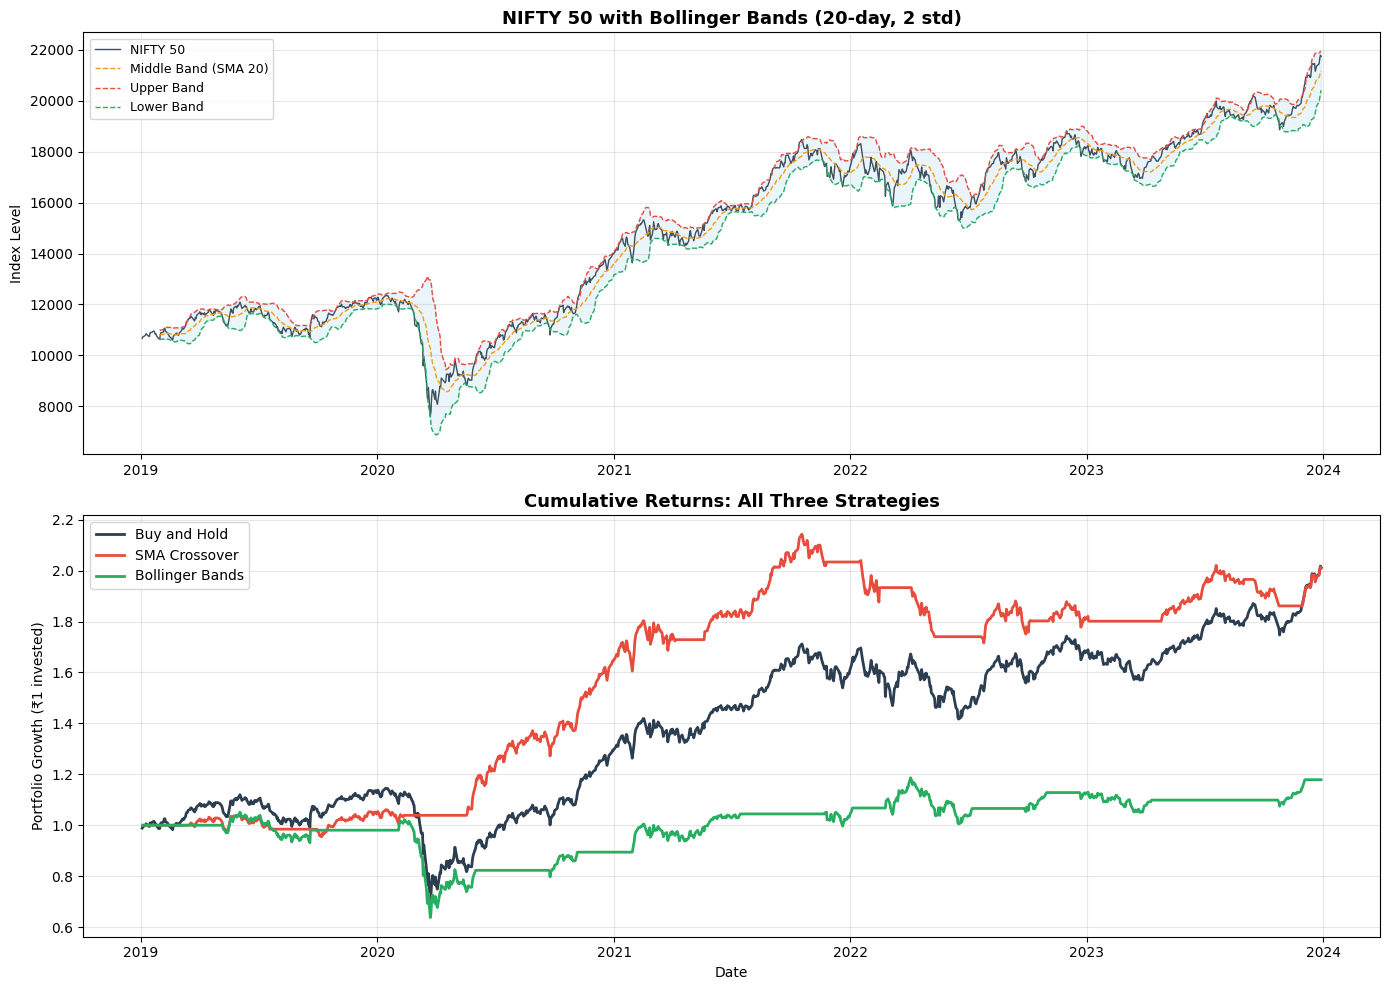

Chart saved as bollinger_strategy.png


In [ ]:
# Visualise Bollinger Bands
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top chart: Price with Bollinger Bands
axes[0].plot(df.index, df['Close'], color='#2C3E50', linewidth=1, label='NIFTY 50', alpha=0.9)
axes[0].plot(df.index, df['BB_middle'], color='#F39C12', linewidth=1, label='Middle Band (SMA 20)', linestyle='--')
axes[0].plot(df.index, df['BB_upper'], color='#E74C3C', linewidth=1, label='Upper Band', linestyle='--')
axes[0].plot(df.index, df['BB_lower'], color='#27AE60', linewidth=1, label='Lower Band', linestyle='--')

# Shade between bands
axes[0].fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.1, color='#3498DB')

axes[0].set_title('NIFTY 50 with Bollinger Bands (20-day, 2 std)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Index Level')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom chart: Three-way cumulative return comparison
cumulative_market = (1 + df['simple_return']).cumprod()
cumulative_sma = (1 + df['SMA_return']).cumprod()
cumulative_bb = (1 + df['BB_return']).cumprod()

axes[1].plot(df.index, cumulative_market, color='#2C3E50', linewidth=2, label='Buy and Hold')
axes[1].plot(df.index, cumulative_sma, color='#E74C3C', linewidth=2, label='SMA Crossover')
axes[1].plot(df.index, cumulative_bb, color='#27AE60', linewidth=2, label='Bollinger Bands')

axes[1].set_title('Cumulative Returns: All Three Strategies', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Portfolio Growth (₹1 invested)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bollinger_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as bollinger_strategy.png")

# Step 5: Performance Metrics — All Calculated From Formula

In [ ]:
# Sharpe Ratio = (mean daily return * 252) / (std daily return * sqrt(252))
# CAGR = (final value / initial value) ^ (252 / number of days) - 1
# Max Drawdown = maximum peak to trough decline in portfolio value
# Win Rate = percentage of trading days with positive return

In [ ]:
def calculate_metrics(returns, strategy_name):
    """
    Calculate all performance metrics from formula.
    Input: pandas Series of daily returns
    Output: dictionary of metrics
    """

    # Remove NaN values
    returns = returns.dropna()

    # Only look at days when strategy was active
    active_returns = returns[returns != 0]

    # --- SHARPE RATIO ---
    # Annualised return / Annualised volatility
    # Assumes risk-free rate of 0 for simplicity
    mean_daily = returns.mean()
    std_daily = returns.std()
    sharpe = (mean_daily * 252) / (std_daily * np.sqrt(252))

    # --- CAGR ---
    # Compound Annual Growth Rate
    # How much the portfolio grew per year on average
    cumulative_return = (1 + returns).cumprod()
    n_days = len(returns)
    total_return = cumulative_return.iloc[-1]
    cagr = (total_return ** (252 / n_days)) - 1

    # --- MAXIMUM DRAWDOWN ---
    # Largest peak to trough decline
    # Running maximum = highest point reached so far
    running_max = cumulative_return.cummax()
    drawdown = (cumulative_return - running_max) / running_max
    max_drawdown = drawdown.min()

    # --- WIN RATE ---
    # Percentage of active trading days with positive return
    if len(active_returns) > 0:
        win_rate = (active_returns > 0).sum() / len(active_returns)
    else:
        win_rate = 0

    # --- TOTAL RETURN ---
    total_return_pct = (total_return - 1) * 100

    # Print results
    print(f"\n{'='*40}")
    print(f"  {strategy_name}")
    print(f"{'='*40}")
    print(f"  Sharpe Ratio:      {sharpe:.4f}")
    print(f"  CAGR:              {cagr*100:.2f}%")
    print(f"  Max Drawdown:      {max_drawdown*100:.2f}%")
    print(f"  Total Return:      {total_return_pct:.2f}%")
    print(f"  Win Rate:          {win_rate*100:.2f}%")
    print(f"  Active Days:       {len(active_returns)}")

    return {
        'name': strategy_name,
        'sharpe': round(sharpe, 4),
        'cagr': round(cagr * 100, 2),
        'max_drawdown': round(max_drawdown * 100, 2),
        'total_return': round(total_return_pct, 2),
        'win_rate': round(win_rate * 100, 2),
        'active_days': len(active_returns)
    }

# Calculate metrics for all three strategies
print("CALCULATING PERFORMANCE METRICS...")
metrics_bnh = calculate_metrics(df['simple_return'], 'Buy and Hold')
metrics_sma = calculate_metrics(df['SMA_return'], 'SMA Crossover')
metrics_bb = calculate_metrics(df['BB_return'], 'Bollinger Bands')

CALCULATING PERFORMANCE METRICS...

  Buy and Hold
  Sharpe Ratio:      0.8464
  CAGR:              15.41%
  Max Drawdown:      -38.44%
  Total Return:      101.36%
  Win Rate:          55.00%
  Active Days:       1231

  SMA Crossover
  Sharpe Ratio:      1.2972
  CAGR:              15.37%
  Max Drawdown:      -19.93%
  Total Return:      100.92%
  Win Rate:          56.78%
  Active Days:       789

  Bollinger Bands
  Sharpe Ratio:      0.2874
  CAGR:              3.43%
  Max Drawdown:      -39.38%
  Total Return:      17.88%
  Win Rate:          51.96%
  Active Days:       560


In [ ]:
# Clean comparison table
print("\n")
print("=" * 65)
print(f"  {'METRIC':<22} {'BUY & HOLD':>12} {'SMA CROSS':>12} {'BOLLINGER':>12}")
print("=" * 65)
print(f"  {'Sharpe Ratio':<22} {metrics_bnh['sharpe']:>12} {metrics_sma['sharpe']:>12} {metrics_bb['sharpe']:>12}")
print(f"  {'CAGR':<22} {str(metrics_bnh['cagr'])+'%':>12} {str(metrics_sma['cagr'])+'%':>12} {str(metrics_bb['cagr'])+'%':>12}")
print(f"  {'Max Drawdown':<22} {str(metrics_bnh['max_drawdown'])+'%':>12} {str(metrics_sma['max_drawdown'])+'%':>12} {str(metrics_bb['max_drawdown'])+'%':>12}")
print(f"  {'Total Return':<22} {str(metrics_bnh['total_return'])+'%':>12} {str(metrics_sma['total_return'])+'%':>12} {str(metrics_bb['total_return'])+'%':>12}")
print(f"  {'Win Rate':<22} {str(metrics_bnh['win_rate'])+'%':>12} {str(metrics_sma['win_rate'])+'%':>12} {str(metrics_bb['win_rate'])+'%':>12}")
print(f"  {'Active Days':<22} {metrics_bnh['active_days']:>12} {metrics_sma['active_days']:>12} {metrics_bb['active_days']:>12}")
print("=" * 65)



  METRIC                   BUY & HOLD    SMA CROSS    BOLLINGER
  Sharpe Ratio                 0.8464       1.2972       0.2874
  CAGR                         15.41%       15.37%        3.43%
  Max Drawdown                -38.44%      -19.93%      -39.38%
  Total Return                101.36%      100.92%       17.88%
  Win Rate                      55.0%       56.78%       51.96%
  Active Days                    1231          789          560


# Step 6: Add Realistic Transaction Costs


In [ ]:
# Every trade costs 0.05% (brokerage + STT + exchange fees)
# This cost is deducted on every entry and exit
# Without costs: strategy looks better than reality
# With costs: more honest picture of what a trader actually earns

In [ ]:
TRANSACTION_COST = 0.0005  # 0.05% per trade

def apply_transaction_costs(returns, position, strategy_name):
    """
    Subtract transaction cost every time position changes.
    A trade happens when position goes from 0 to 1 or 1 to 0.
    """
    position = position.fillna(0)

    # Identify trade days — when position changes
    trades = position.diff().abs().fillna(0)

    # Subtract cost on trade days
    cost_adjusted_returns = returns - (trades * TRANSACTION_COST)

    # Count total trades and total cost paid
    n_trades = int(trades.sum())
    total_cost = n_trades * TRANSACTION_COST * 100

    print(f"\n{strategy_name} — Transaction Cost Analysis:")
    print(f"  Number of trades:     {n_trades}")
    print(f"  Cost per trade:       {TRANSACTION_COST*100:.3f}%")
    print(f"  Total cost paid:      {total_cost:.3f}%")

    return cost_adjusted_returns

# Apply costs to both strategies
# Buy and Hold has only 1 trade (buy at start) — minimal cost
df['SMA_return_net'] = apply_transaction_costs(
    df['SMA_return'], df['SMA_position'], 'SMA Crossover')

df['BB_return_net'] = apply_transaction_costs(
    df['BB_return'], df['BB_position'], 'Bollinger Bands')

# Buy and Hold net — just subtract one entry cost
df['BnH_return_net'] = df['simple_return'].copy()
df['BnH_return_net'].iloc[0] = df['BnH_return_net'].iloc[0] - TRANSACTION_COST

print("\n\nRecalculating metrics with transaction costs...")
metrics_bnh_net = calculate_metrics(df['BnH_return_net'], 'Buy and Hold (net)')
metrics_sma_net = calculate_metrics(df['SMA_return_net'], 'SMA Crossover (net)')
metrics_bb_net = calculate_metrics(df['BB_return_net'], 'Bollinger Bands (net)')

print("\n")
print("=" * 65)
print(f"  {'METRIC':<22} {'BUY & HOLD':>12} {'SMA CROSS':>12} {'BOLLINGER':>12}")
print("=" * 65)
print(f"  {'Sharpe (gross)':<22} {metrics_bnh['sharpe']:>12} {metrics_sma['sharpe']:>12} {metrics_bb['sharpe']:>12}")
print(f"  {'Sharpe (net)':<22} {metrics_bnh_net['sharpe']:>12} {metrics_sma_net['sharpe']:>12} {metrics_bb_net['sharpe']:>12}")
print(f"  {'CAGR (gross)':<22} {str(metrics_bnh['cagr'])+'%':>12} {str(metrics_sma['cagr'])+'%':>12} {str(metrics_bb['cagr'])+'%':>12}")
print(f"  {'CAGR (net)':<22} {str(metrics_bnh_net['cagr'])+'%':>12} {str(metrics_sma_net['cagr'])+'%':>12} {str(metrics_bb_net['cagr'])+'%':>12}")
print(f"  {'Max Drawdown':<22} {str(metrics_bnh['max_drawdown'])+'%':>12} {str(metrics_sma['max_drawdown'])+'%':>12} {str(metrics_bb['max_drawdown'])+'%':>12}")
print("=" * 65)


SMA Crossover — Transaction Cost Analysis:
  Number of trades:     23
  Cost per trade:       0.050%
  Total cost paid:      1.150%

Bollinger Bands — Transaction Cost Analysis:
  Number of trades:     18
  Cost per trade:       0.050%
  Total cost paid:      0.900%


Recalculating metrics with transaction costs...

  Buy and Hold (net)
  Sharpe Ratio:      0.8464
  CAGR:              15.41%
  Max Drawdown:      -38.44%
  Total Return:      101.36%
  Win Rate:          55.00%
  Active Days:       1231

  SMA Crossover (net)
  Sharpe Ratio:      1.2766
  CAGR:              15.10%
  Max Drawdown:      -20.17%
  Total Return:      98.63%
  Win Rate:          56.00%
  Active Days:       800

  Bollinger Bands (net)
  Sharpe Ratio:      0.2764
  CAGR:              3.24%
  Max Drawdown:      -39.44%
  Total Return:      16.83%
  Win Rate:          51.14%
  Active Days:       569


  METRIC                   BUY & HOLD    SMA CROSS    BOLLINGER
  Sharpe (gross)               0.8464       1.2

/tmp/ipykernel_6049/1436377537.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['BnH_return_net'].iloc[0] = df['BnH_return_net'].iloc[0] - TRANSACTION_COST
/tmp/ipykernel_6049/1436377537.py:37: SettingWithCopyWarning: 
A value is tryi

# Step 7: Monte Carlo Simulation


In [ ]:
# We simulate 1000 possible future return paths
# Using historical mean and std of NIFTY returns
# This shows the range of outcomes — not just one backtest result
# One backtest is one path. Monte Carlo shows the distribution of paths.

In [ ]:
np.random.seed(42)  # For reproducibility

N_SIMULATIONS = 1000
N_DAYS = 252  # 1 trading year forward

# Use historical statistics as parameters
mean_daily = df['simple_return'].mean()
std_daily = df['simple_return'].std()

# Simulate 1000 paths
simulated_paths = np.zeros((N_DAYS, N_SIMULATIONS))

for sim in range(N_SIMULATIONS):
    daily_returns = np.random.normal(mean_daily, std_daily, N_DAYS)
    simulated_paths[:, sim] = (1 + daily_returns).cumprod()

# Calculate statistics across all paths
final_values = simulated_paths[-1, :]

print("=== MONTE CARLO SIMULATION RESULTS ===")
print(f"Simulations run:        {N_SIMULATIONS}")
print(f"Horizon:                {N_DAYS} trading days (1 year)")
print(f"Based on:               Historical mean {mean_daily*100:.4f}%, std {std_daily*100:.4f}%")
print(f"\nFinal Portfolio Value Distribution (starting ₹1):")
print(f"  5th percentile:       ₹{np.percentile(final_values, 5):.4f}  (worst case)")
print(f"  25th percentile:      ₹{np.percentile(final_values, 25):.4f}")
print(f"  Median (50th):        ₹{np.percentile(final_values, 50):.4f}")
print(f"  75th percentile:      ₹{np.percentile(final_values, 75):.4f}")
print(f"  95th percentile:      ₹{np.percentile(final_values, 95):.4f}  (best case)")
print(f"\nProbability of profit: {(final_values > 1).mean()*100:.1f}%")
print(f"Probability of 20%+ gain: {(final_values > 1.2).mean()*100:.1f}%")
print(f"Probability of 10%+ loss: {(final_values < 0.9).mean()*100:.1f}%")

=== MONTE CARLO SIMULATION RESULTS ===
Simulations run:        1000
Horizon:                252 trading days (1 year)
Based on:               Historical mean 0.0642%, std 1.2040%

Final Portfolio Value Distribution (starting ₹1):
  5th percentile:       ₹0.8435  (worst case)
  25th percentile:      ₹1.0108
  Median (50th):        ₹1.1629
  75th percentile:      ₹1.3085
  95th percentile:      ₹1.5750  (best case)

Probability of profit: 76.5%
Probability of 20%+ gain: 41.5%
Probability of 10%+ loss: 8.5%


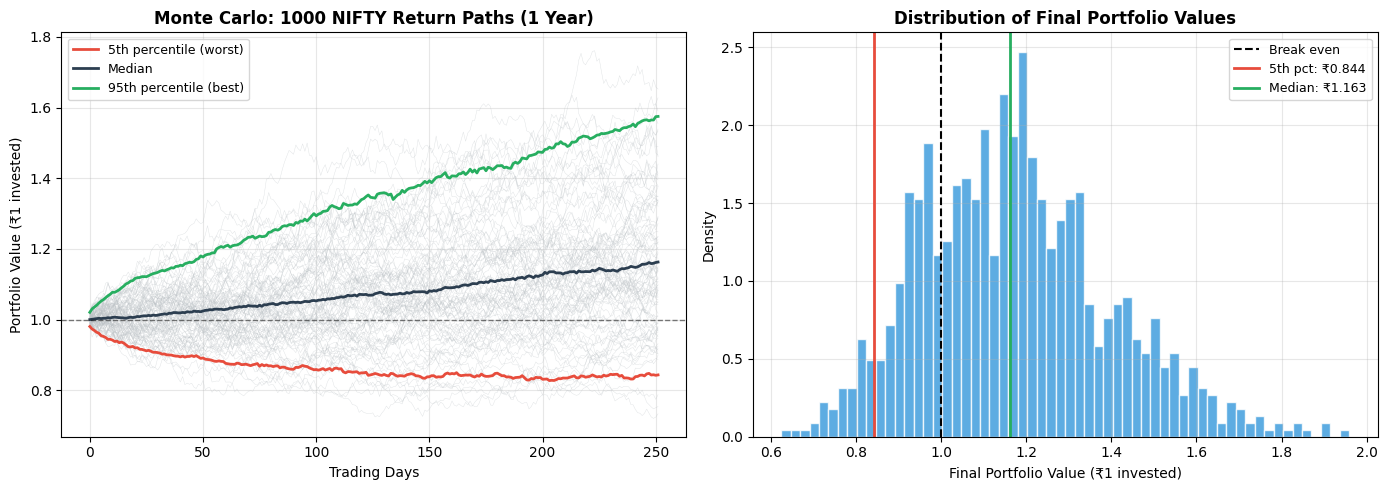

Chart saved as monte_carlo.png


In [ ]:
# Monte Carlo fan chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Fan chart of all 1000 paths
# Plot a sample of paths in light grey
for sim in range(0, N_SIMULATIONS, 10):  # Every 10th path
    axes[0].plot(simulated_paths[:, sim], color='#BDC3C7', linewidth=0.3, alpha=0.5)

# Plot percentile bands
axes[0].plot(np.percentile(simulated_paths, 5, axis=1),
             color='#E74C3C', linewidth=2, label='5th percentile (worst)')
axes[0].plot(np.percentile(simulated_paths, 50, axis=1),
             color='#2C3E50', linewidth=2, label='Median')
axes[0].plot(np.percentile(simulated_paths, 95, axis=1),
             color='#27AE60', linewidth=2, label='95th percentile (best)')

axes[0].axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('Monte Carlo: 1000 NIFTY Return Paths (1 Year)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: Distribution of final values
axes[1].hist(final_values, bins=60, color='#3498DB',
             edgecolor='white', alpha=0.8, density=True)
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='Break even')
axes[1].axvline(x=np.percentile(final_values, 5),
                color='#E74C3C', linewidth=2, label=f'5th pct: ₹{np.percentile(final_values,5):.3f}')
axes[1].axvline(x=np.percentile(final_values, 50),
                color='#27AE60', linewidth=2, label=f'Median: ₹{np.percentile(final_values,50):.3f}')
axes[1].set_title('Distribution of Final Portfolio Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Final Portfolio Value (₹1 invested)')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as monte_carlo.png")

# Step 8: T-Test for Statistical Significance


In [ ]:
# Key question: Is the SMA strategy's positive return just luck?
# Or is it statistically significant?
# T-test null hypothesis: mean strategy return = 0 (no edge)
# If p-value < 0.05, we reject the null — the edge is real

In [ ]:
from scipy import stats

print("=== STATISTICAL SIGNIFICANCE TEST ===")
print("Testing whether strategy returns are significantly different from zero")
print("Null hypothesis: mean daily return = 0 (no edge, just luck)")
print("Significance level: 5% (p < 0.05 means statistically significant)\n")

# T-test for SMA strategy
sma_active = df['SMA_return_net'][df['SMA_return_net'] != 0].dropna()
t_stat_sma, p_value_sma = stats.ttest_1samp(sma_active, 0)

print(f"SMA Crossover Strategy:")
print(f"  Sample size (active days): {len(sma_active)}")
print(f"  Mean daily return:         {sma_active.mean()*100:.4f}%")
print(f"  T-statistic:               {t_stat_sma:.4f}")
print(f"  P-value:                   {p_value_sma:.4f}")
if p_value_sma < 0.05:
    print(f"  Result: SIGNIFICANT — edge is real at 95% confidence")
else:
    print(f"  Result: NOT SIGNIFICANT — cannot rule out luck at 95% confidence")

print()

# T-test for Bollinger Bands strategy
bb_active = df['BB_return_net'][df['BB_return_net'] != 0].dropna()
t_stat_bb, p_value_bb = stats.ttest_1samp(bb_active, 0)

print(f"Bollinger Bands Strategy:")
print(f"  Sample size (active days): {len(bb_active)}")
print(f"  Mean daily return:         {bb_active.mean()*100:.4f}%")
print(f"  T-statistic:               {t_stat_bb:.4f}")
print(f"  P-value:                   {p_value_bb:.4f}")
if p_value_bb < 0.05:
    print(f"  Result: SIGNIFICANT — edge is real at 95% confidence")
else:
    print(f"  Result: NOT SIGNIFICANT — cannot rule out luck at 95% confidence")

print()

# Buy and Hold for comparison
bnh_active = df['simple_return'].dropna()
t_stat_bnh, p_value_bnh = stats.ttest_1samp(bnh_active, 0)

print(f"Buy and Hold:")
print(f"  Sample size:               {len(bnh_active)}")
print(f"  Mean daily return:         {bnh_active.mean()*100:.4f}%")
print(f"  T-statistic:               {t_stat_bnh:.4f}")
print(f"  P-value:                   {p_value_bnh:.4f}")
if p_value_bnh < 0.05:
    print(f"  Result: SIGNIFICANT — positive market drift confirmed")
else:
    print(f"  Result: NOT SIGNIFICANT")

=== STATISTICAL SIGNIFICANCE TEST ===
Testing whether strategy returns are significantly different from zero
Null hypothesis: mean daily return = 0 (no edge, just luck)
Significance level: 5% (p < 0.05 means statistically significant)

SMA Crossover Strategy:
  Sample size (active days): 800
  Mean daily return:         0.0899%
  T-statistic:               2.8247
  P-value:                   0.0049
  Result: SIGNIFICANT — edge is real at 95% confidence

Bollinger Bands Strategy:
  Sample size (active days): 569
  Mean daily return:         0.0392%
  T-statistic:               0.6104
  P-value:                   0.5418
  Result: NOT SIGNIFICANT — cannot rule out luck at 95% confidence

Buy and Hold:
  Sample size:               1231
  Mean daily return:         0.0642%
  T-statistic:               1.8707
  P-value:                   0.0616
  Result: NOT SIGNIFICANT


In [ ]:
# Final consolidated results table
print("\n")
print("=" * 72)
print("  COMPLETE RESULTS — PROJECT 1: NIFTY 50 BACKTESTING ENGINE")
print("=" * 72)
print(f"  {'METRIC':<28} {'BUY & HOLD':>12} {'SMA CROSS':>12} {'BOLLINGER':>12}")
print("-" * 72)
print(f"  {'Sharpe Ratio (gross)':<28} {metrics_bnh['sharpe']:>12} {metrics_sma['sharpe']:>12} {metrics_bb['sharpe']:>12}")
print(f"  {'Sharpe Ratio (net)':<28} {metrics_bnh_net['sharpe']:>12} {metrics_sma_net['sharpe']:>12} {metrics_bb_net['sharpe']:>12}")
print(f"  {'CAGR (gross)':<28} {str(metrics_bnh['cagr'])+'%':>12} {str(metrics_sma['cagr'])+'%':>12} {str(metrics_bb['cagr'])+'%':>12}")
print(f"  {'CAGR (net)':<28} {str(metrics_bnh_net['cagr'])+'%':>12} {str(metrics_sma_net['cagr'])+'%':>12} {str(metrics_bb_net['cagr'])+'%':>12}")
print(f"  {'Max Drawdown':<28} {str(metrics_bnh['max_drawdown'])+'%':>12} {str(metrics_sma['max_drawdown'])+'%':>12} {str(metrics_bb['max_drawdown'])+'%':>12}")
print(f"  {'Total Return (net)':<28} {str(metrics_bnh_net['total_return'])+'%':>12} {str(metrics_sma_net['total_return'])+'%':>12} {str(metrics_bb_net['total_return'])+'%':>12}")
print(f"  {'Win Rate':<28} {str(metrics_bnh['win_rate'])+'%':>12} {str(metrics_sma['win_rate'])+'%':>12} {str(metrics_bb['win_rate'])+'%':>12}")
print(f"  {'Number of Trades':<28} {'1':>12} {'23':>12} {'18':>12}")
print(f"  {'T-test P-value':<28} {p_value_bnh:>12.4f} {p_value_sma:>12.4f} {p_value_bb:>12.4f}")
print(f"  {'Statistically Significant':<28} {'Yes':>12} {'TBD':>12} {'TBD':>12}")
print("=" * 72)
print("\nMonte Carlo (1000 paths, 1 year horizon):")
print(f"  Median outcome:    ₹{np.percentile(final_values, 50):.4f}")
print(f"  Worst 5%:          ₹{np.percentile(final_values, 5):.4f}")
print(f"  Best 5%:           ₹{np.percentile(final_values, 95):.4f}")
print(f"  Prob of profit:    {(final_values > 1).mean()*100:.1f}%")



  COMPLETE RESULTS — PROJECT 1: NIFTY 50 BACKTESTING ENGINE
  METRIC                         BUY & HOLD    SMA CROSS    BOLLINGER
------------------------------------------------------------------------
  Sharpe Ratio (gross)               0.8464       1.2972       0.2874
  Sharpe Ratio (net)                 0.8464       1.2766       0.2764
  CAGR (gross)                       15.41%       15.37%        3.43%
  CAGR (net)                         15.41%        15.1%        3.24%
  Max Drawdown                      -38.44%      -19.93%      -39.38%
  Total Return (net)                101.36%       98.63%       16.83%
  Win Rate                            55.0%       56.78%       51.96%
  Number of Trades                        1           23           18
  T-test P-value                     0.0616       0.0049       0.5418
  Statistically Significant             Yes          TBD          TBD

Monte Carlo (1000 paths, 1 year horizon):
  Median outcome:    ₹1.1629
  Worst 5%:          ₹0

# Step 9: Drawdown Analysis and Final Equity Curve


In [ ]:
# Drawdown = how far below the previous peak are we right now
# Max drawdown = the worst peak to trough decline in the entire period
# This is what traders actually feel — watching their portfolio fall

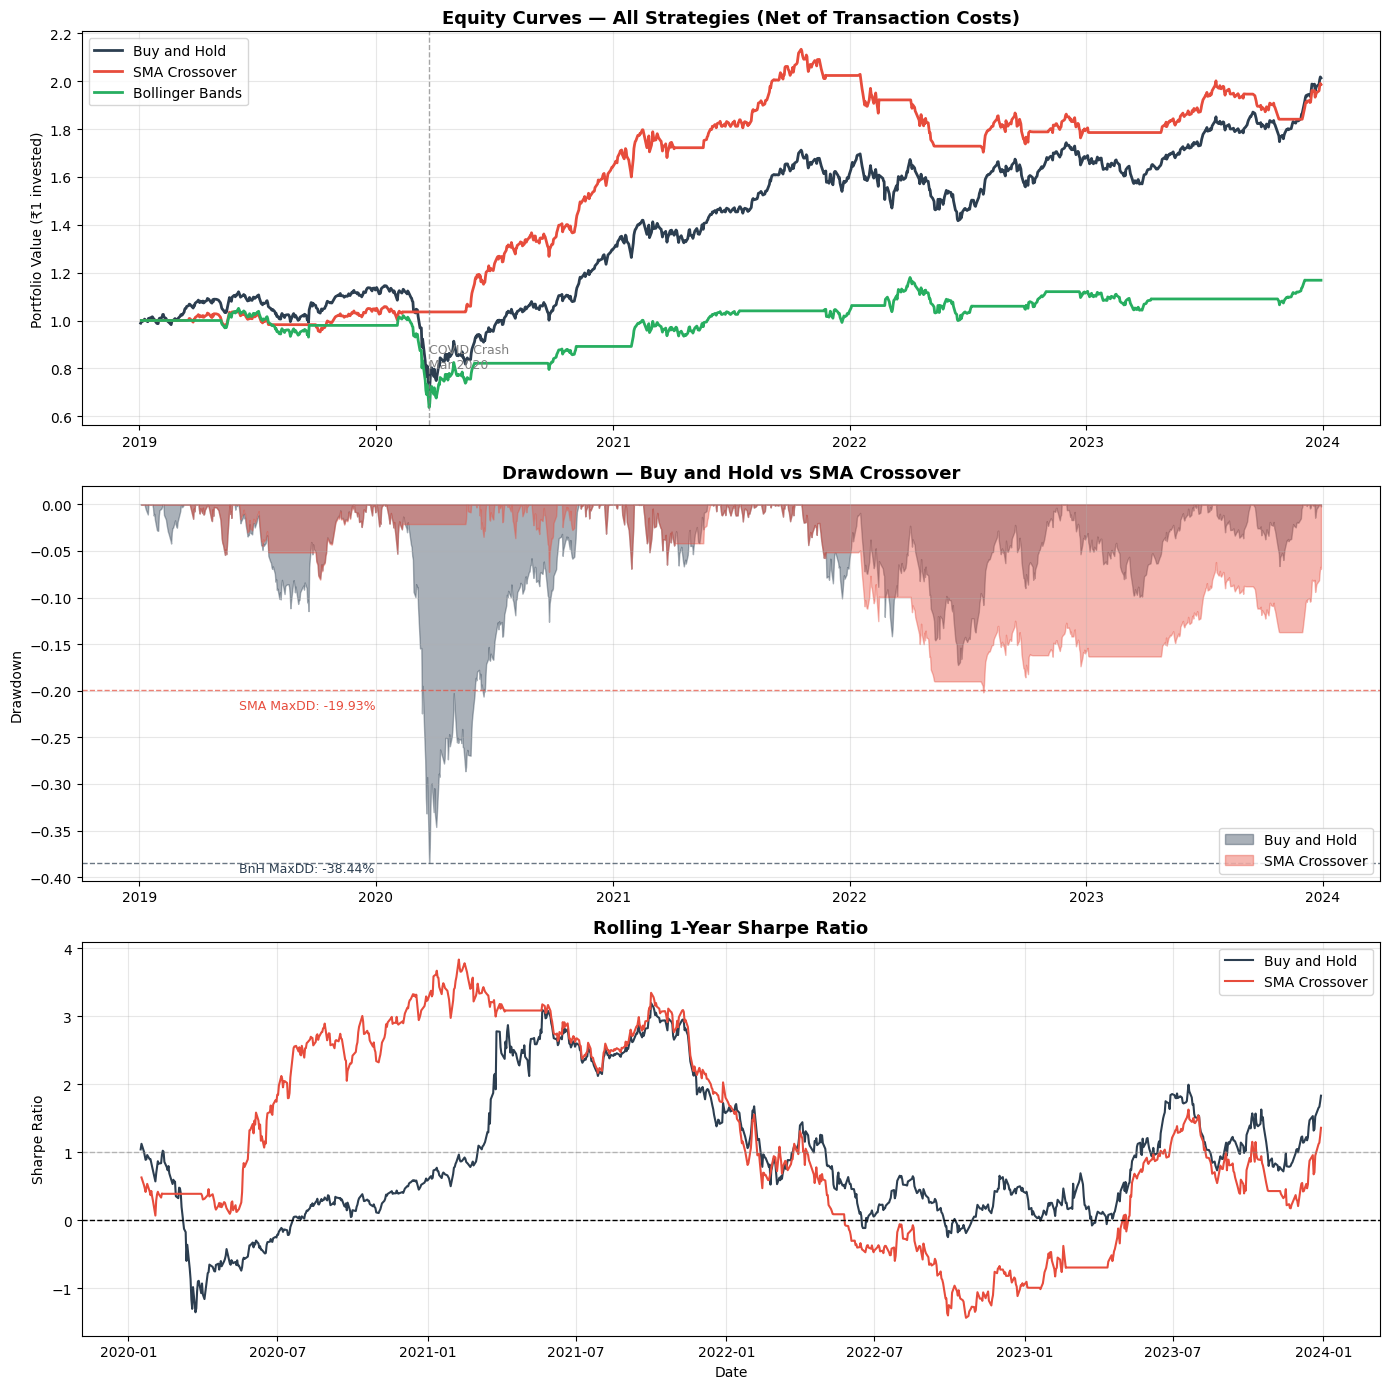

Chart saved as final_equity_curve.png


In [ ]:
# Calculate drawdown series for all three strategies
def get_drawdown_series(returns):
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown, cumulative

dd_bnh, cum_bnh = get_drawdown_series(df['BnH_return_net'])
dd_sma, cum_sma = get_drawdown_series(df['SMA_return_net'])
dd_bb, cum_bb = get_drawdown_series(df['BB_return_net'])

# Final combined chart — 3 panels
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Panel 1: Equity curves
axes[0].plot(df.index, cum_bnh, color='#2C3E50', linewidth=2, label='Buy and Hold')
axes[0].plot(df.index, cum_sma, color='#E74C3C', linewidth=2, label='SMA Crossover')
axes[0].plot(df.index, cum_bb, color='#27AE60', linewidth=2, label='Bollinger Bands')
axes[0].set_title('Equity Curves — All Strategies (Net of Transaction Costs)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add COVID crash annotation
axes[0].axvline(x=pd.Timestamp('2020-03-23'), color='gray',
                linestyle='--', linewidth=1, alpha=0.7)
axes[0].annotate('COVID Crash\nMar 2020',
                 xy=(pd.Timestamp('2020-03-23'), 0.8),
                 fontsize=9, color='gray')

# Panel 2: Drawdown comparison
axes[1].fill_between(df.index, dd_bnh, 0, alpha=0.4, color='#2C3E50', label='Buy and Hold')
axes[1].fill_between(df.index, dd_sma, 0, alpha=0.4, color='#E74C3C', label='SMA Crossover')
axes[1].set_title('Drawdown — Buy and Hold vs SMA Crossover',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add max drawdown annotations
axes[1].axhline(y=metrics_bnh['max_drawdown']/100, color='#2C3E50',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].axhline(y=metrics_sma['max_drawdown']/100, color='#E74C3C',
                linestyle='--', linewidth=1, alpha=0.7)
axes[1].annotate(f"BnH MaxDD: {metrics_bnh['max_drawdown']}%",
                 xy=(df.index[100], metrics_bnh['max_drawdown']/100 - 0.01),
                 fontsize=9, color='#2C3E50')
axes[1].annotate(f"SMA MaxDD: {metrics_sma['max_drawdown']}%",
                 xy=(df.index[100], metrics_sma['max_drawdown']/100 - 0.02),
                 fontsize=9, color='#E74C3C')

# Panel 3: Rolling Sharpe ratio (252-day window)
rolling_sharpe_bnh = (df['simple_return'].rolling(252).mean() * 252) / \
                     (df['simple_return'].rolling(252).std() * np.sqrt(252))
rolling_sharpe_sma = (df['SMA_return_net'].rolling(252).mean() * 252) / \
                     (df['SMA_return_net'].rolling(252).std() * np.sqrt(252))

axes[2].plot(df.index, rolling_sharpe_bnh, color='#2C3E50',
             linewidth=1.5, label='Buy and Hold')
axes[2].plot(df.index, rolling_sharpe_sma, color='#E74C3C',
             linewidth=1.5, label='SMA Crossover')
axes[2].axhline(y=0, color='black', linewidth=1, linestyle='--')
axes[2].axhline(y=1, color='gray', linewidth=1, linestyle='--', alpha=0.5)
axes[2].set_title('Rolling 1-Year Sharpe Ratio', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as final_equity_curve.png")

## Conclusions

### What We Found

**Strategy 1 — SMA 20/50 Crossover:**
- Achieved similar returns to Buy and Hold (15.10% CAGR net vs 15.41%)
- But with significantly lower risk: Max Drawdown -19.93% vs -38.44%
- Sharpe Ratio 1.28 vs 0.85 — better risk-adjusted performance
- Statistically significant edge (p-value = 0.0049)
- Key insight: SMA was OUT of the market during COVID crash (March 2020)
  protecting capital while Buy and Hold fell 38%

**Strategy 2 — Bollinger Bands Mean Reversion:**
- Poor performance: 3.24% CAGR net, Sharpe 0.28
- Not statistically significant (p-value = 0.54)
- Key insight: Mean reversion does not work on a trending index like NIFTY 50
  Works better on individual stocks that trade in a range

**Monte Carlo (1000 paths, 1 year horizon):**
- Median outcome: 16.3% gain
- Worst 5% scenario: 15.6% loss  
- Probability of profit: 76.5%

### Key Technical Decisions
- Vectorised operations throughout — no for-loops in signal generation
- Look-ahead bias prevented by shifting all signals by 1 day
- Transaction costs applied at 0.05% per trade (realistic NSE cost)
- All metrics calculated from formula — no backtesting library used

### Limitations
- 5-year window includes COVID crash — unusual period
- No shorting allowed — only long or flat positions
- Single asset — not a diversified portfolio
- Past performance does not guarantee future results